# Family Model - Base Model

This notebook showcases our pipeline in action, for the "family" label classification task. This is our baseline model applying only image resizing and standardization.

## Imports

The imports are composed of a mix of third-party libraries and several modules and constants that we have custom built to fit our needs.

In [21]:
# Standard Library
from datetime import date

# Third-party libraries
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # type: ignore
from tensorflow.keras.metrics import AUC # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator, smart_resize  # type: ignore
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Internal modules
from deep.constants import BATCH_SIZE, INPUT_DIR, METADATA_DIR, METADATA_FILE, MODEL_IMAGE_SIZE, SEEDS, MODELS, MODEL_CONFIGS
from deep.modelling.metric_utils import get_fitted_model_metrics, plot_metrics
from deep.modelling.pipiline_utils import split_data
from deep.preprocess.album_augmenter import compute_effective_class_weights
from deep.modelling.custom_loss import CategoricalFocalLoss
from deep.modelling.model_specifications import efficient_net

## Loading Metadata and Splits

The foremost task is to obtain the metadata for our image files.

In [22]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum','is_animal'], inplace=True)

data

,rare_species_id,family,file_path
0,75fd91cb-2881-41cd-88e6-de451e8b60e2,unionidae,12853737_449393.jpg
1,28c508bc-63ff-4e60-9c8f-1934367e1528,geoemydidae,20969394_793083.jpg
2,00372441-588c-4af8-9665-29bee20822c0,cryptobranchidae,28895411_319982.jpg
3,29cc6040-6af2-49ee-86ec-ab7d89793828,turdidae,29658536_45510188.jpg
4,94004bff-3a33-4758-8125-bf72e6e57eab,indriidae,21252576_7250886.jpg
...,...,...,...
11978,1fa96ea5-32fa-4a25-b8d2-fa99f6e2cb89,leporidae,29734618_1011315.jpg
11979,628bf2b4-6ecc-4017-a8e6-4306849e0cfc,emydidae,29972861_1056842.jpg
11980,0ecfdec9-b1cd-4d43-96fc-2f8889ec1ad9,dasyatidae,30134195_52572074.jpg
11981,27fdb1e9-c5fb-459a-8b6a-6fb222b1c512,mustelidae,9474963_46559139.jpg


In [23]:
# Splitting the indices
train_df, val_df, test_df = split_data(data, 'family', seed=SEEDS[0])

Per our framework, the oversamples that we created before and stored can be accessed by a common key with the main metadata.csv, and simply concatenated.

## Image Generator

Image generator is setup with conservative values, as animal features like faces are not invariant under rotation. Test images were standardized according to the IMAGENET standard.

In [24]:
# Image Generator
train_datagen = ImageDataGenerator(
        rotation_range=90,
        shear_range=0.2,
        brightness_range=[0.8, 1.2],
        horizontal_flip=True,
        channel_shift_range=30.0,
        zoom_range=(0.8, 1.2),
        fill_mode='nearest',
        preprocessing_function=lambda image: smart_resize(image, size=MODEL_IMAGE_SIZE['efficientnetb4'])
    )

test_datagen = ImageDataGenerator(
        preprocessing_function=lambda image: smart_resize(image, size=MODEL_IMAGE_SIZE['efficientnetb4'])
    )

**Note: we were unable to debug the issue shown above with 232 images, however it was deemed to not be a source of data leakage, as far as we can diagnose it. .**

## Flow_from

Flow from dataframe along side each generator setup for each of the data splits.

In [25]:
# Train generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='family',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEEDS[0],
    shuffle=True
)

# Validation generator
val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='family',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Test generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='family',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8148 validated image filenames belonging to 202 classes.
Found 1438 validated image filenames belonging to 202 classes.
Found 2397 validated image filenames belonging to 202 classes.


## Weights

Our loss function of choice was the MultiClass Focal Loss, a derivation of the Focal Loss.

In [26]:
# Map class weights from labels - indices using the generator
label_map = train_generator.class_indices
weights_str = compute_effective_class_weights(train_df, 'family')
weights_idx = {label_map[k]: v for k, v in weights_str.items()}

# Convert to list for alpha
alpha = [weights_idx[i] for i in range(len(weights_idx))]

# Instantiate focal loss
loss = CategoricalFocalLoss(gamma=5, alpha=alpha)

num_classes = train_df['family'].nunique()

## Model Instanciation and Compilation

Our model is then instanced, and compiled, RMSprop was found to be a stable option.

In [27]:
# Get the model and its configuration
model, config = efficient_net(
    num_classes=num_classes,
    regularizer=False,
    dropout=False,
    task_type='multiclass'
)

# Now compile the model
model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss=loss,  # CategoricalFocalLoss
    metrics=['accuracy', AUC(multi_label=False), 'precision', 'recall']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 380, 380,  │          0 │ input_layer_2[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 380, 380,  │          0 │ lambda_2[0][0]    │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 380, 380,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 380, 380,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 381, 381,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 190, 190,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 190, 190,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 190, 190,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 190, 190,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 190, 190,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 190, 190,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 190, 190,  │          0 │ block1a_activati

 Total params: 17,920,809 (68.36 MB)

 Trainable params: 246,858 (964.29 KB)

 Non-trainable params: 17,673,951 (67.42 MB)

## Model Training

The model is trained.

In [28]:
# Fit the model
fitted_model = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE)),
    validation_steps=int(np.ceil(len(val_df) / BATCH_SIZE)),
    class_weight=weights_idx,  # mapped int class weights
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ],
    verbose=1
)

/home/nottoriousgg/miniconda3/envs/deep/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 902s 3s/step - accuracy: 0.0377 - auc_2: 0.5876 - loss: 3.1221 - precision: 0.4611 - recall: 2.5884e-04 - val_accuracy: 0.1259 - val_auc_2: 0.7469 - val_loss: 2.1708 - val_precision: 0.6944 - val_recall: 0.0174 - learning_rate: 0.0010
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 857s 3s/step - accuracy: 0.1594 - auc_2: 0.7944 - loss: 1.6168 - precision: 0.8973 - recall: 0.0163 - val_accuracy: 0.1989 - val_auc_2: 0.8853 - val_loss: 1.5228 - val_precision: 0.6602 - val_recall: 0.0473 - learning_rate: 0.0010
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 845s 3s/step - accuracy: 0.2517 - auc_2: 0.9121 - loss: 1.0830 - precision: 0.8317 - recall: 0.0445 - val_accuracy: 0.2796 - val_auc_2: 0.9207 - val_loss: 1.2558 - val_precision: 0.7062 - val_recall: 0.0953 - learning_rate: 0.0010
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 866s 3s/step - accuracy: 0.3230 - auc_2: 0.9326 - loss: 0.8178 - precision: 0.8492 - recall: 0.0982 - val_accuracy: 0.2872 - val_auc_2: 0.9154 

## Evaluate Model

Lastly we evaluate our model both in the training and in the test sets.

### Training metrics

We plot the training metrics.

Train Loss: 0.25601333379745483
Validation Loss: 0.7980383038520813
Train Precision:0.8371298313140869
Validation Precision: 0.7782805562019348
Best validation precision was: 0.7782805562019348


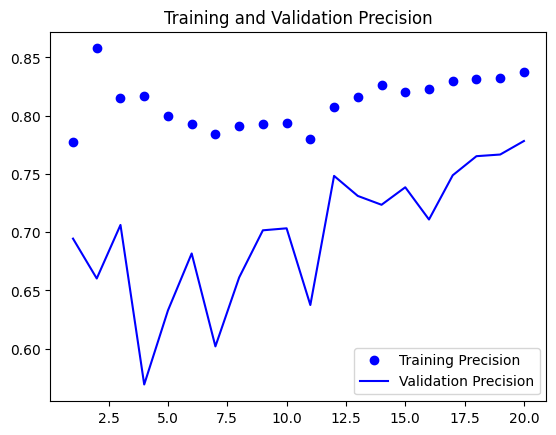

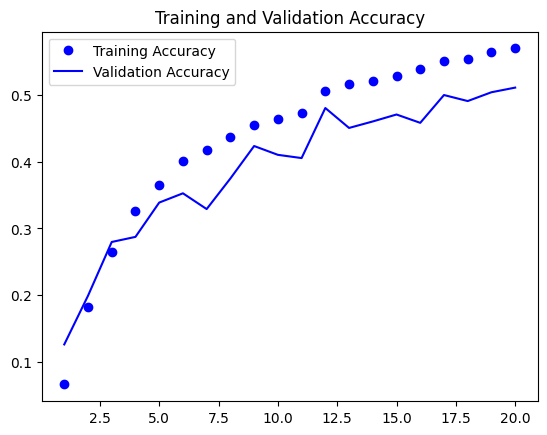

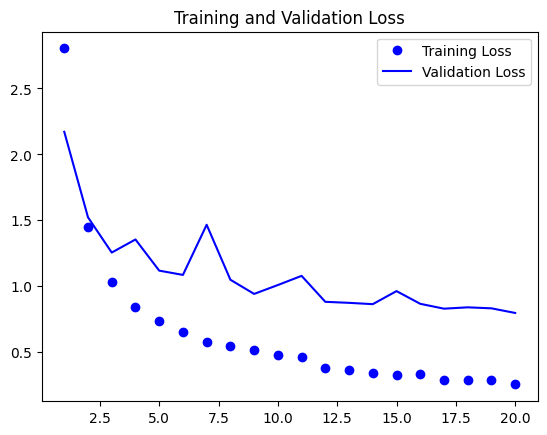

In [29]:
# Get best epoch precision
val_precision = get_fitted_model_metrics(fitted_model)

print(f"Best validation precision was: {val_precision}")

# Plot training metrics
plot_metrics(fitted_model)

### Test metrics

And predict the test set via test generator, and then evaluate the results.

In [30]:
# Predicting results on the test set
y_pred_proba = model.predict(test_generator, steps=len(test_generator), verbose=1)

# Obtaining our classification metadata
y_pred_classes = np.argmax(y_pred_proba, axis=1)
y_true_classes = test_generator.classes
class_indices = test_generator.class_indices
class_labels = list(class_indices.keys())

75/75 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step


In [31]:
# Accuracy
print("Accuracy:", accuracy_score(y_true_classes, y_pred_classes))

# F1 Scores
f1_macro = f1_score(y_true_classes, y_pred_classes, average='macro')
f1_weighted = f1_score(y_true_classes, y_pred_classes, average='weighted')
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Precision
precision_macro = precision_score(y_true_classes, y_pred_classes, average='macro')
precision_weighted = precision_score(y_true_classes, y_pred_classes, average='weighted')
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")

# Recall
recall_macro = recall_score(y_true_classes, y_pred_classes, average='macro')
recall_weighted = recall_score(y_true_classes, y_pred_classes, average='weighted')
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

Accuracy: 0.5465164789319983
F1 Score (Macro): 0.5670
F1 Score (Weighted): 0.5381
Precision (Macro): 0.5706
Precision (Weighted): 0.6131
Recall (Macro): 0.6233
Recall (Weighted): 0.5465

Classification Report:
                   precision    recall  f1-score   support

     accipitridae       0.69      0.46      0.55        24
    acipenseridae       0.42      0.61      0.50        18
      acroporidae       0.87      0.31      0.46        42
         agamidae       0.36      0.42      0.38        12
      agariciidae       0.43      0.12      0.19        24
        albulidae       0.33      0.50      0.40         6
      alcedinidae       0.33      0.67      0.44         6
    alligatoridae       0.27      0.67      0.38         6
        alopiidae       0.22      0.42      0.29        12
   ambystomatidae       0.40      0.50      0.44        12
         anatidae       0.83      0.42      0.56        36
         anguidae       0.50      0.75      0.60        12
          aotidae     

## Logging and Saving

The model architecture is then stored in `.json` format, and the weights are stored in `.h5` format.

In [ ]:
today = date.today().isoformat()
nickname = input("Add nickname to this model for future reference.")

weight_filename = f"model_{nickname}_weights_{today}.weights.h5"
config_filename = f"model_{nickname}_architecture_{today}.json"

# Save model weights
weights_path = MODELS / weight_filename
model.save_weights(weights_path)

# Save the model architecture
model_config_path = MODEL_CONFIGS / config_filename
model_json = model.to_json()
with open(model_config_path, "w") as json_file:
    json_file.write(model_json)